## Chargement des données nettoyées

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, silhouette_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from sklearn.cluster import KMeans

df_students = pd.read_csv("Data/students_clean.csv")
df_employee = pd.read_csv("Data/employee_clean.csv")

## Comparaison de plusieurs modèles supervisés

In [2]:
def test_models(df, label):
    print("Moyenne :\n", df.mean())
    print("Ecart type :\n", df.std())

    df.boxplot(figsize=(24, 10))
    plt.show()

    X = df.drop('Depression', axis=1)
    y = df['Depression']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    lr = LogisticRegression(max_iter=1000)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    dt = DecisionTreeClassifier(random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    ada = AdaBoostClassifier(n_estimators=100, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

    classifiers = [
        ('Logistic Regression', lr),
        ('Random Forest', rf),
        ('Decision Tree', dt),
        ('K-Nearest Neighbors', knn),
        ('AdaBoost', ada),
        ('Gradient Boosting', gb)
    ]

    plt.figure()
    for name, model in classifiers:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        print(name)
        print("accuracy:", accuracy_score(y_test, y_pred))
        print("precision:", precision_score(y_test, y_pred))
        print("recall:", recall_score(y_test, y_pred))
        print("f1:", f1_score(y_test, y_pred))

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

    vc = VotingClassifier(estimators=classifiers)
    vc.fit(X_train, y_train)
    y_pred2 = vc.predict(X_test)

    print(f'{label} Accuracy Voting Classifier : {accuracy_score(y_test, y_pred2):.2f}')
    print(f'{label} F1 Score Voting Classifier : {f1_score(y_test, y_pred2):.2f}\n')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('Faux Positifs (FPR)')
    plt.ylabel('Vrais Positifs - Recall (TPR)')
    plt.title(f'Courbe ROC: cas {label}')
    plt.legend()
    plt.show()

Moyenne :
 Gender                                    0.531873
Age                                      26.241036
Academic Pressure                         3.003984
CGPA                                      7.567809
Study Satisfaction                        3.075697
Sleep Duration                            6.529880
Dietary Habits                            1.015936
Degree                                    1.864542
Have you ever had suicidal thoughts ?     0.517928
Work/Study Hours                          6.404382
Financial Stress                          2.928287
Family History of Mental Illness          0.472112
Depression                                0.501992
dtype: float64
Ecart type :
 Gender                                   0.499481
Age                                      4.896501
Academic Pressure                        1.390007
CGPA                                     1.465367
Study Satisfaction                       1.373490
Sleep Duration                           1.5824

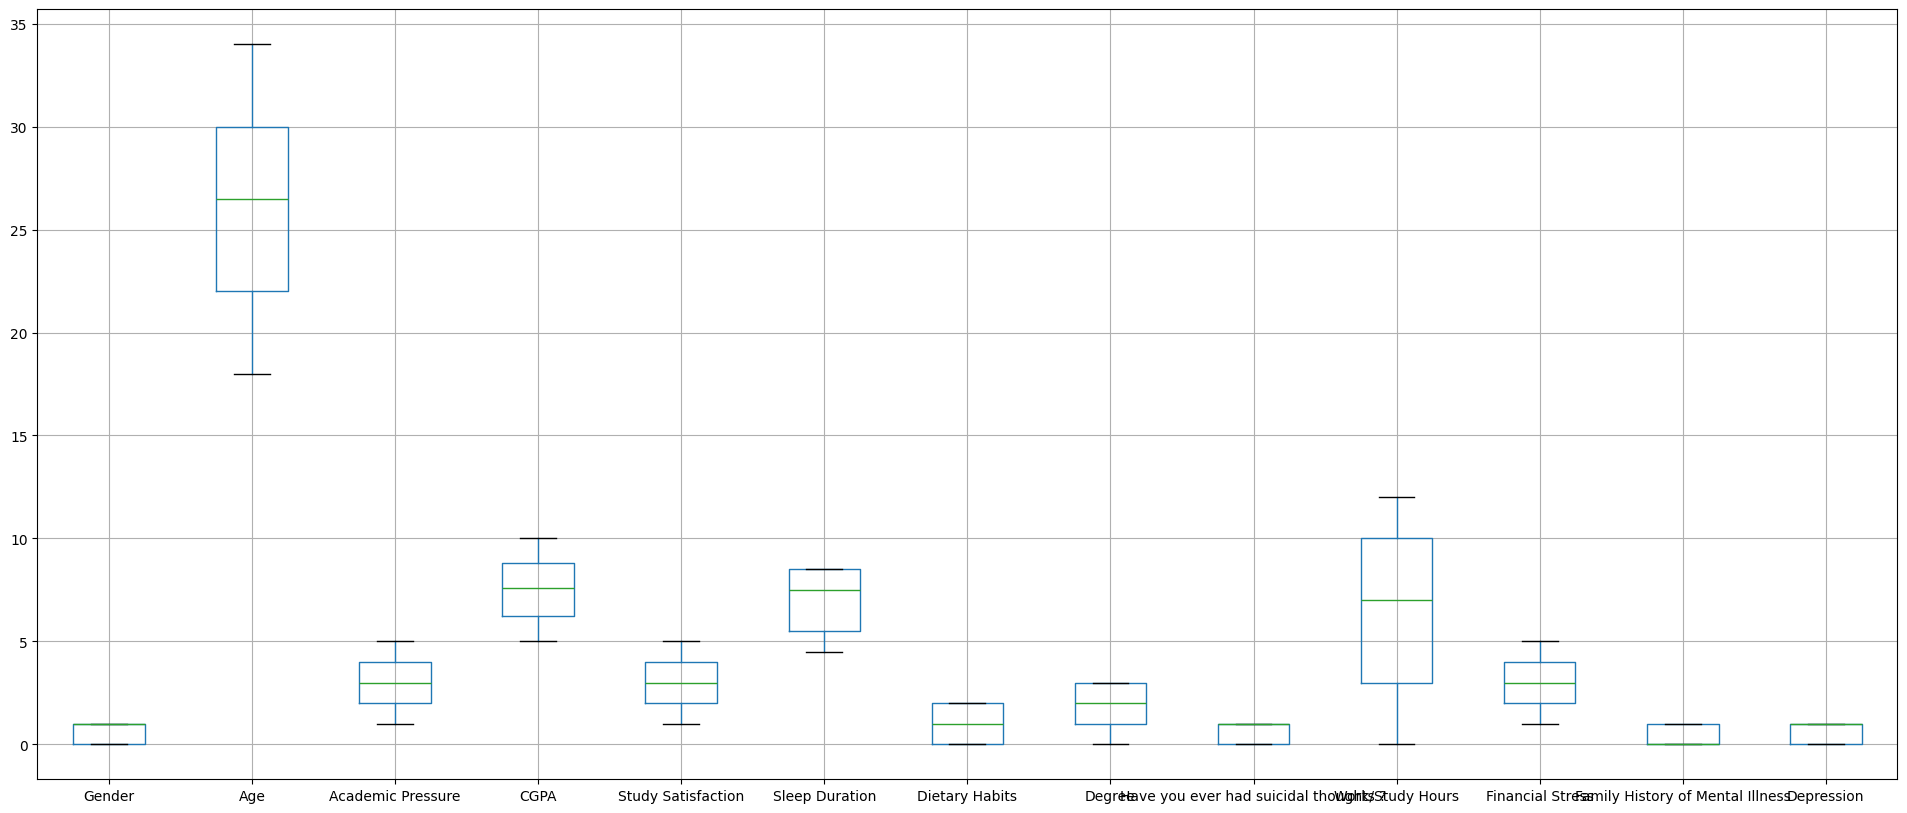

Logistic Regression
accuracy: 0.9702970297029703
precision: 0.9629629629629629
recall: 0.9811320754716981
f1: 0.9719626168224299
Random Forest
accuracy: 0.9306930693069307
precision: 0.896551724137931
recall: 0.9811320754716981
f1: 0.9369369369369369
Decision Tree
accuracy: 0.8712871287128713
precision: 0.8571428571428571
recall: 0.9056603773584906
f1: 0.8807339449541285
K-Nearest Neighbors
accuracy: 0.8811881188118812
precision: 0.8596491228070176
recall: 0.9245283018867925
f1: 0.8909090909090909
AdaBoost
accuracy: 0.9801980198019802
precision: 0.9811320754716981
recall: 0.9811320754716981
f1: 0.9811320754716981
Gradient Boosting
accuracy: 0.9405940594059405
precision: 0.9122807017543859
recall: 0.9811320754716981
f1: 0.9454545454545454
students Accuracy Voting Classifier : 0.98
students F1 Score Voting Classifier : 0.98



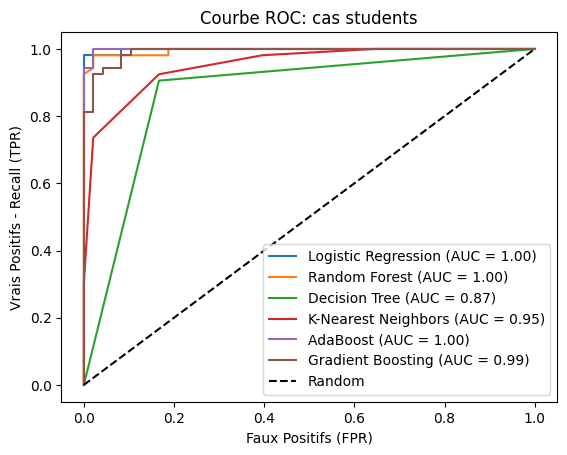

In [3]:
test_models(df_students, "students")

Moyenne :
 Gender                                    0.518987
Age                                      42.171860
Profession                                2.808666
Work Pressure                             3.021908
Job Satisfaction                          3.015093
Sleep Duration                            6.481986
Dietary Habits                            1.015579
Degree                                    2.185005
Have you ever had suicidal thoughts ?     0.481500
Work/Study Hours                          5.930867
Financial Stress                          2.978578
Family History of Mental Illness          0.490750
Depression                                0.098832
dtype: float64
Ecart type :
 Gender                                    0.499761
Age                                      11.461202
Profession                                1.936121
Work Pressure                             1.417312
Job Satisfaction                          1.418432
Sleep Duration                            

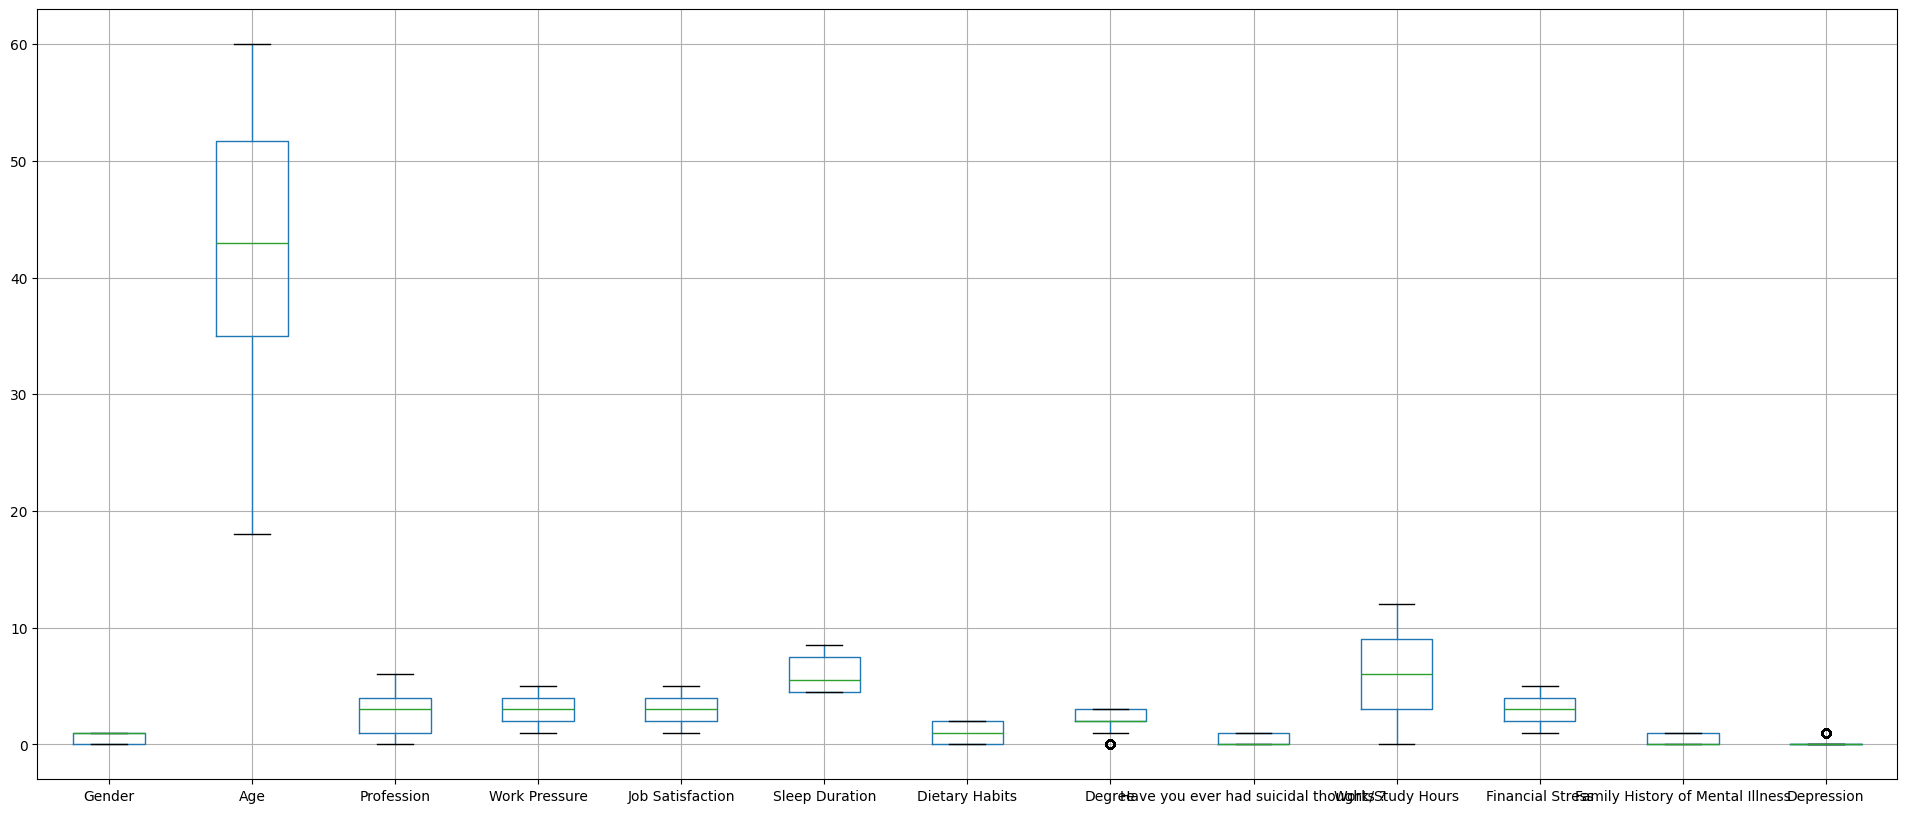

Logistic Regression
accuracy: 0.9902676399026764
precision: 1.0
recall: 0.9069767441860465
f1: 0.9512195121951219
Random Forest
accuracy: 0.9464720194647201
precision: 0.9565217391304348
recall: 0.5116279069767442
f1: 0.6666666666666666
Decision Tree
accuracy: 0.9172749391727494
precision: 0.6285714285714286
recall: 0.5116279069767442
f1: 0.5641025641025641
K-Nearest Neighbors
accuracy: 0.9391727493917275
precision: 0.8461538461538461
recall: 0.5116279069767442
f1: 0.6376811594202898
AdaBoost
accuracy: 0.9854014598540146
precision: 1.0
recall: 0.8604651162790697
f1: 0.925
Gradient Boosting
accuracy: 0.9635036496350365
precision: 0.9375
recall: 0.6976744186046512
f1: 0.8
employee Accuracy Voting Classifier : 0.96
employee F1 Score Voting Classifier : 0.75



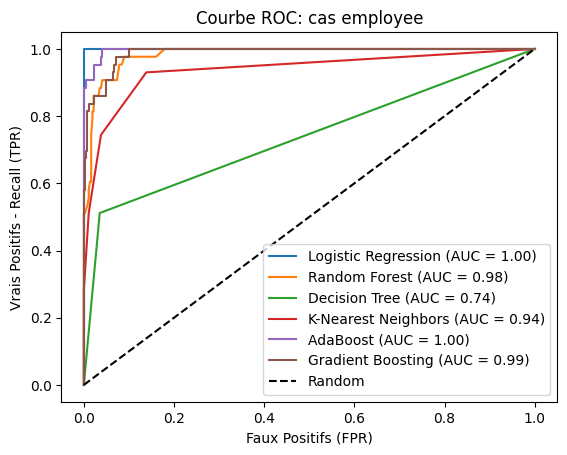

In [4]:
test_models(df_employee, "employee")

Meilleur modèle : régression logistique, sur les deux datasets.

## Essai non supervisé : KMeans

In [5]:
def test_kmeans(df, label):
    X = df.drop('Depression', axis=1)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    clustering_score = []
    for i in range(1, 20):
        kmeans = KMeans(n_clusters=i, random_state=42)
        kmeans.fit(X_scaled)
        clustering_score.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 20), clustering_score)
    plt.xlabel('Nombre de clusters')
    plt.ylabel('Inertie')
    plt.xticks(range(1, 20))
    plt.title(f'Méthode du coude : {label}')
    plt.show()

    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans.fit(X_scaled)
    pred = kmeans.predict(X_scaled)

    print(pred)

    df_result = df.copy()
    df_result['Cluster'] = pd.DataFrame(pred, columns=['cluster'])

    labels = kmeans.labels_
    print(f'{label} Silhouette Score : {silhouette_score(X_scaled, labels, metric="euclidean"):.2f}')

    ct = pd.crosstab(df_result['Cluster'], df['Depression'])
    print(ct)

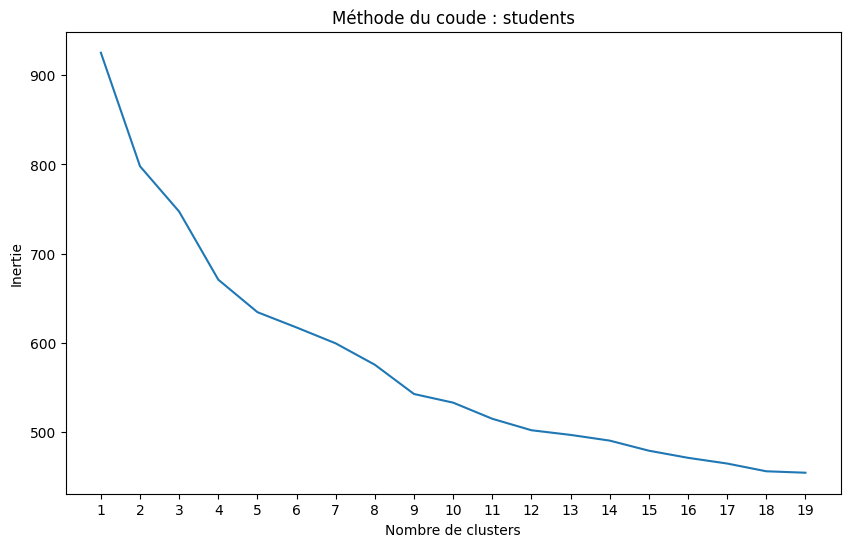

[0 0 0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1
 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 0 0
 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1
 0 1 1 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1
 0 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0
 0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 1 0 0 0
 1 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1
 0 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 1 1 1
 1 0 1 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 1 0
 0 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1
 0 1 1 0 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1
 0 1 1 1 1 1 0 0 0 0 0 1 

In [6]:
test_kmeans(df_students, "students")

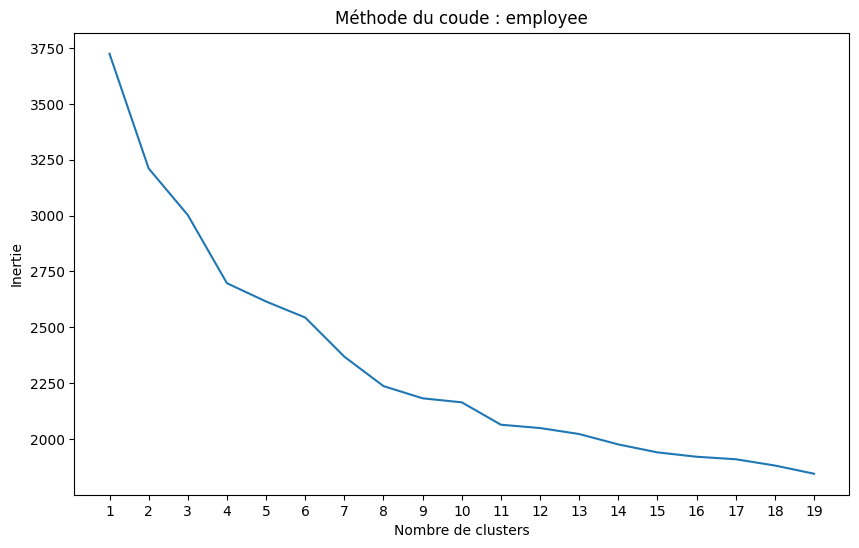

[1 0 1 ... 1 1 1]
employee Silhouette Score : 0.14
Depression    0    1
Cluster             
0           963  103
1           888  100


In [7]:
test_kmeans(df_employee, "employee")

## Conclusion

Le silhouette score est faible (0.14, proche de 0) donc les clusters se chevauchent, et la courbe du coude ne présente pas de coude net à k=2.

Les données ne forment pas deux clusters nets pour Depression Oui/Non : d'après le crosstab, les deux clusters ont à peu près la même proportion de personnes déprimées / non déprimées, donc les groupes ne se forment pas selon la dépression.

Le modèle non supervisé n'est donc pas exploitable (proche du hasard) : on reste sur la régression logistique, en apprentissage supervisé.

Prochaine étape : construire le pipeline final pour ce modèle (matrice de corrélation, feature importance, GridSearchCV, matrice de confusion, courbe ROC).